# ChemRover experiments

This notebook runs **the same pipeline as `uv run chemrover`** (`chemrover.cli.run`), but lets you change the defaults and compare runs side by side.

Changes use the same override strings as the command line:

| Change | Override |
|---|---|
| Model | `"model=rf"` (xgb, rf, svm, knn) |
| Dataset | `"data.subset=2"` (1 Byadi, 2 Griffiths, 3 PCCP, 4 combined) |
| Drop solvent (structure only) | `"data.features=[lambda,SMILES]"` |
| Split seed | `"data.seed=7"` |
| Tuning (test) / benchmark (val) fraction | `"data.test_size=0.1"`, `"data.val_size=0.2"` |
| Descriptor coverage filter | `"data.coverage_thresh=0.95"` |
| Tuning budget | `"trainer.n_trials=50"` |
| A fixed model param (only used if not tuned) | `"model.max_depth=4"` |

Every run is saved to `outputs/notebook/<date>/<time>_<label>/` in the same layout as a CLI run (model, parity plot, `metrics.json`, `predictions.csv`, `.hydra/config.yaml`), so **section 6** can compare everything you've ever run, from the notebook or the CLI.

> Kernel: select the project's `.venv` interpreter (`uv sync` installs `ipykernel`).

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import optuna
import pandas as pd
from omegaconf import OmegaConf

from chemrover.experiment import compose_cfg, run_experiment, run_grid, product, parity_grid, load_runs
from chemrover.util import setup_logging

setup_logging()                                            # ChemRover messages to the console
optuna.logging.set_verbosity(optuna.logging.WARNING)       # hide Optuna's per-trial messages
pd.set_option("display.precision", 3)

C:\Users\ollyb\Documents_Local\Code\ChemRover\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Defaults
The resolved config every run starts from. Edit the YAML files in `config/` to change the defaults permanently, or pass overrides below to change them for one run.

In [2]:
print(OmegaConf.to_yaml(compose_cfg(), resolve=True))

model:
  _target_: chemrover.models.xgb.XGB
  name: absorbance_model
  load_from: null
  max_depth: 2
  learning_rate: 0.02
  n_estimators: 1000
  subsample: 0.5
  colsample_bytree: 0.5
  min_child_weight: 3
  gamma: 1.0
  early_stopping_rounds: 50
  n_jobs: 1
  enable_categorical: true
  tree_method: hist
data:
  name: absorption
  path: C:/Users/ollyb/Documents_Local/Code/ChemRover/data/raw
  subset: 4
  features:
  - lambda
  - SMILES
  - solvent
  required:
  - lambda
  - SMILES
  - solvent
  max_samples: null
  train_fraction: 1.0
  target: lambda
  categorical_features:
  - solvent
  test_size: 0.1
  val_size: 0.15
  seed: 42
  encoding: rdkit
  coverage_thresh: 0.9
trainer:
  kf_n_splits: 5
  kf_shuffle: true
  kf_random_state: 42
  study_dir: C:/Users/ollyb/Documents_Local/Code/ChemRover/outputs/optuna
  n_jobs: -1
  show_progress_bar: true
  n_trials: 100
paths:
  root: C:/Users/ollyb/Documents_Local/Code/ChemRover
  data: C:/Users/ollyb/Documents_Local/Code/ChemRover/data/raw

Overrides applied to **every** run in this notebook. Keep the trial count low while exploring, and raise it for final numbers.
Optuna studies are cached per data + model config, so re-running an identical setup reuses its trials instead of starting again.

In [3]:
QUICK = ["trainer.n_trials=20", "trainer.show_progress_bar=false"]

## 2. Baseline

In [4]:
baseline = run_experiment("baseline", QUICK)
baseline.metrics

    [INFO] 17:32:57 [Md:experiment Fn:run_experiment] === baseline: ['trainer.n_trials=20', 'trainer.show_progress_bar=false']
    [INFO] 17:33:06 [Md:optim_hp Fn:optimise_hyper_params] Study 'absorbance_model_180dea13': 80 trials done, running 0 more
    [INFO] 17:33:06 [Md:optim_hp Fn:optimise_hyper_params] Best test RMSE 17.049 with params {'max_depth': 8, 'learning_rate': 0.06541821473314273, 'n_estimators': 2504, 'subsample': 0.6290101975389802, 'colsample_bytree': 0.6605839989206406, 'min_child_weight': 3, 'gamma': 4.54411713028876}
    [INFO] 17:33:08 [Md:experiment Fn:run] Val metrics: {'rmse': 17.53197138455609, 'mae': 8.984423265389516, 'r2': 0.9194255005300055, 'n_train': 700, 'n_val': 141, 'n_test': 93, 'n_features': 218}
    [INFO] 17:33:08 [Md:xgb Fn:save] Saved model to C:\Users\ollyb\Documents_Local\Code\ChemRover\outputs\notebook\2026-09-26\17-32-57_baseline\absorbance_model.json


{'rmse': 17.53197138455609,
 'mae': 8.984423265389516,
 'r2': 0.9194255005300055,
 'n_train': 700,
 'n_val': 141,
 'n_test': 93,
 'n_features': 218}

## 3. One change at a time
Change a single setting and compare it with the baseline.

    [INFO] 17:33:09 [Md:experiment Fn:run_experiment] === with solvent: ['trainer.n_trials=20', 'trainer.show_progress_bar=false']
    [INFO] 17:33:19 [Md:optim_hp Fn:optimise_hyper_params] Study 'absorbance_model_180dea13': 80 trials done, running 0 more
    [INFO] 17:33:19 [Md:optim_hp Fn:optimise_hyper_params] Best test RMSE 17.049 with params {'max_depth': 8, 'learning_rate': 0.06541821473314273, 'n_estimators': 2504, 'subsample': 0.6290101975389802, 'colsample_bytree': 0.6605839989206406, 'min_child_weight': 3, 'gamma': 4.54411713028876}
    [INFO] 17:33:21 [Md:experiment Fn:run] Val metrics: {'rmse': 17.53197138455609, 'mae': 8.984423265389516, 'r2': 0.9194255005300055, 'n_train': 700, 'n_val': 141, 'n_test': 93, 'n_features': 218}
    [INFO] 17:33:21 [Md:xgb Fn:save] Saved model to C:\Users\ollyb\Documents_Local\Code\ChemRover\outputs\notebook\2026-09-26\17-33-09_with_solvent\absorbance_model.json
    [INFO] 17:33:22 [Md:experiment Fn:run_experiment] === no solvent: ['trainer.n_

,rmse,mae,r2,n_train,n_val,n_test,n_features
with solvent,17.532,8.984,0.919,700,141,93,218
no solvent,17.948,9.319,0.916,700,141,93,217


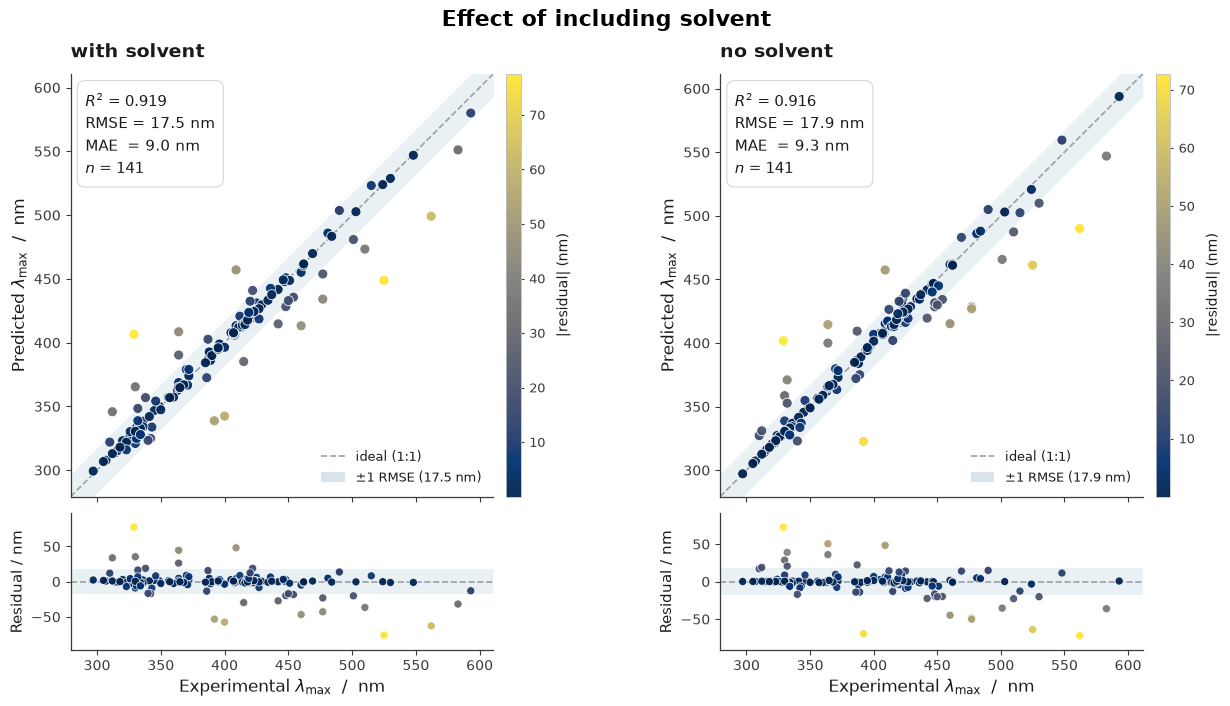

In [5]:
compare_summary, compare = run_grid(
    {"with solvent": [], "no solvent": ["data.features=[lambda,SMILES]"]}, common=QUICK,
)
display(compare_summary)
parity_grid(compare, title="Effect of including solvent")
plt.show()

## 4. Grid of settings
`product()` builds every combination of several axes. Each axis maps a readable label to one override, or a list of overrides.

> Note: rows missing a value in any kept column are dropped, so "with solvent" can train on fewer molecules than "no solvent" (e.g. Byadi has rows with no solvent). Check `n_train` before comparing.

In [6]:
variants = product(
    dataset={
        "Byadi": "data.subset=1",
        "Griffiths": "data.subset=2",
        "PCCP": "data.subset=3",
        "Combined": "data.subset=4",
    },
    solvent={
        "with solvent": [],
        "no solvent": "data.features=[lambda,SMILES]",
    },
)
summary, results = run_grid(variants, common=QUICK)   # index: (dataset, solvent)
summary

    [INFO] 17:33:35 [Md:experiment Fn:run_experiment] === Byadi | with solvent: ['trainer.n_trials=20', 'trainer.show_progress_bar=false', 'data.subset=1']
    [INFO] 17:33:41 [Md:optim_hp Fn:optimise_hyper_params] Study 'absorbance_model_6c0ad25d': 80 trials done, running 0 more
    [INFO] 17:33:41 [Md:optim_hp Fn:optimise_hyper_params] Best test RMSE 27.590 with params {'max_depth': 9, 'learning_rate': 0.14934043018164841, 'n_estimators': 2989, 'subsample': 0.8692181188123533, 'colsample_bytree': 0.7088469914911647, 'min_child_weight': 7, 'gamma': 0.5465463106185375}
    [INFO] 17:33:42 [Md:experiment Fn:run] Val metrics: {'rmse': 29.420960205850637, 'mae': 18.042834614598473, 'r2': 0.8195839926739397, 'n_train': 424, 'n_val': 86, 'n_test': 56, 'n_features': 218}
    [INFO] 17:33:42 [Md:xgb Fn:save] Saved model to C:\Users\ollyb\Documents_Local\Code\ChemRover\outputs\notebook\2026-09-26\17-33-35_Byadi_with_solvent\absorbance_model.json
    [INFO] 17:33:42 [Md:experiment Fn:run_experi

rmse     mae     r2  n_train  n_val  n_test  \
Byadi     with solvent  29.421  18.043  0.820      424     86      56   
          no solvent    31.206  20.541  0.797      424     86      56   
Griffiths with solvent  23.808  16.307  0.874      155     32      20   
          no solvent    24.870  15.907  0.862      155     32      20   
PCCP      with solvent  12.111   8.231  0.897      120     25      16   
          no solvent    15.347  10.155  0.835      120     25      16   
Combined  with solvent  17.532   8.984  0.919      700    141      93   
          no solvent    17.948   9.319  0.916      700    141      93   

                        n_features  
Byadi     with solvent         218  
          no solvent           217  
Griffiths with solvent         218  
          no solvent           217  
PCCP      with solvent         218  
          no solvent           217  
Combined  with solvent         218  
          no solvent           217

In [7]:
# one metric as a dataset x solvent table
summary["r2"].unstack()

,no solvent,with solvent
Byadi,0.797,0.820
Combined,0.916,0.919
Griffiths,0.862,0.874
PCCP,0.835,0.897


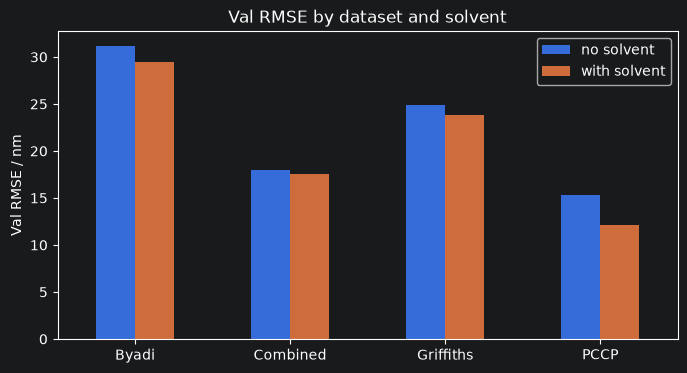

In [8]:
ax = summary["rmse"].unstack().plot.bar(
    rot=0, ylabel="Val RMSE / nm", title="Val RMSE by dataset and solvent", figsize=(8, 4),
)
plt.show()

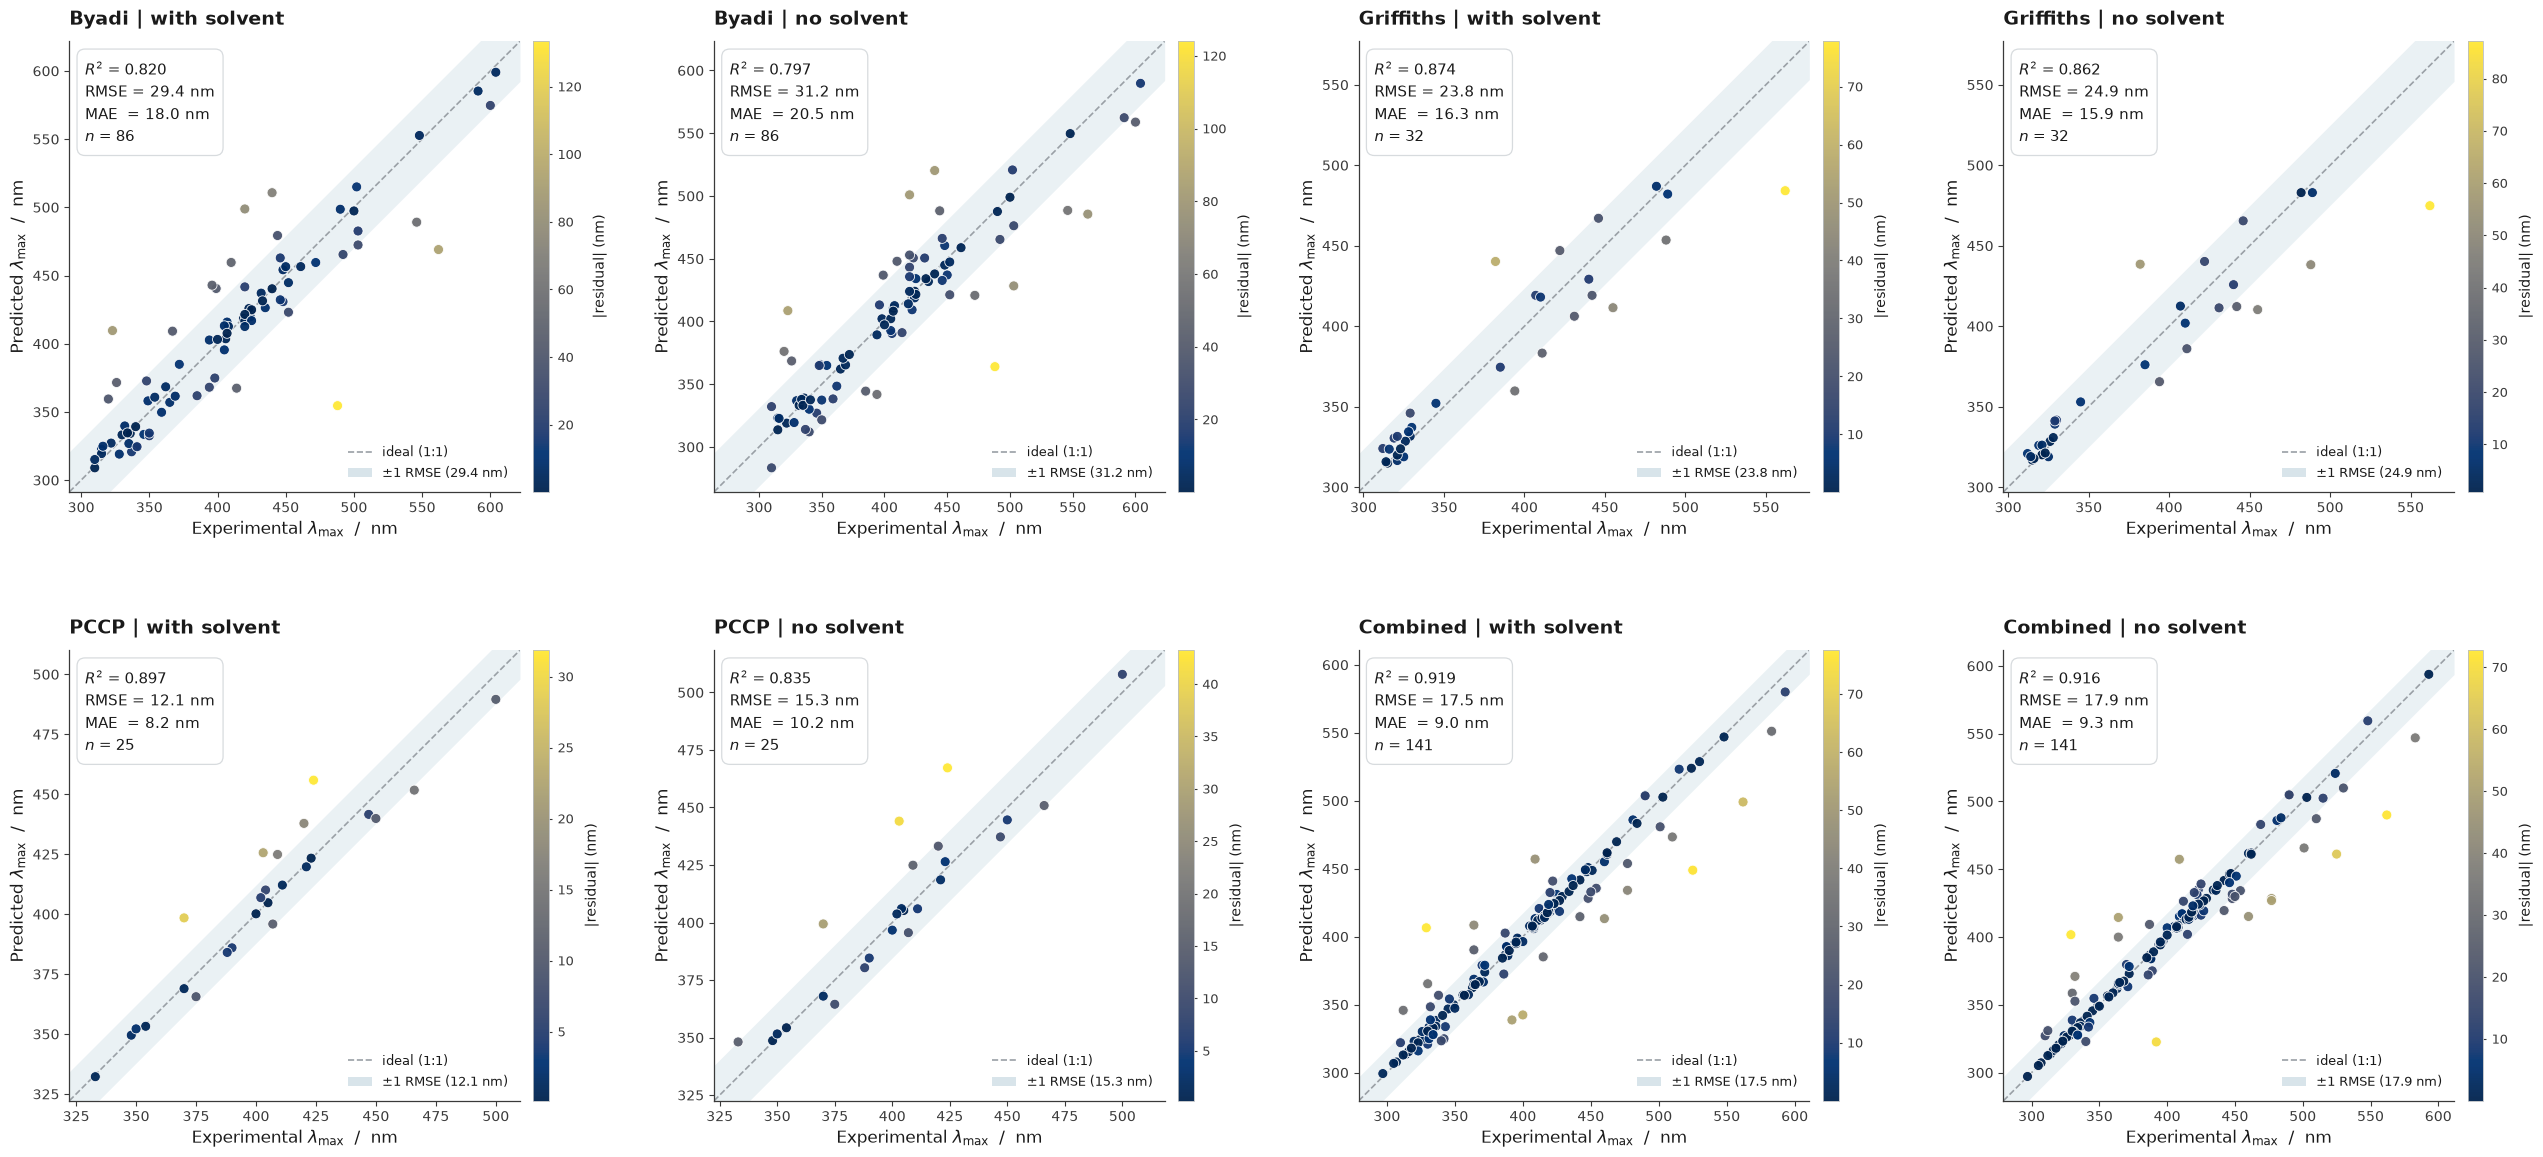

In [9]:
parity_grid(results, ncols=4, show_residuals=False)
plt.show()

## 4b. Compare models
`model=<name>` switches the whole model config group (`config/model/<name>.yaml`). Each model is tuned with its own Optuna search space (`PARAM_LIMS` in `src/chemrover/models/<name>.py`).
Add a dataset or solvent axis to `product()` to see whether the best model depends on the data.

In [10]:
models = product(model={
    "Mean (baseline)": "model=dummy", "PLS": "model=pls", "KNN": "model=knn", "SVM": "model=svm",
    "Random forest": "model=rf", "XGBoost": "model=xgb", "GP": "model=gp", "MLP": "model=mlp",
})
model_summary, model_results = run_grid(models, common=QUICK)
model_summary.sort_values("rmse")

    [INFO] 17:34:51 [Md:experiment Fn:run_experiment] === Mean (baseline): ['trainer.n_trials=20', 'trainer.show_progress_bar=false', 'model=dummy']
    [INFO] 17:35:00 [Md:optim_hp Fn:optimise_hyper_params] 'absorbance_dummy' has no search space; fitting once with the configured params
    [INFO] 17:35:00 [Md:experiment Fn:run] Val metrics: {'rmse': 61.76469591381315, 'mae': 49.03214792299899, 'r2': -3.851212187955255e-05, 'n_train': 700, 'n_val': 141, 'n_test': 93, 'n_features': 218}
    [INFO] 17:35:00 [Md:sklearn_base Fn:save] Saved model to C:\Users\ollyb\Documents_Local\Code\ChemRover\outputs\notebook\2026-09-26\17-34-51_Mean_baseline_\absorbance_dummy.joblib
    [INFO] 17:35:01 [Md:experiment Fn:run_experiment] === PLS: ['trainer.n_trials=20', 'trainer.show_progress_bar=false', 'model=pls']
    [INFO] 17:35:11 [Md:optim_hp Fn:optimise_hyper_params] Study 'absorbance_pls_bb075cc1': 0 trials done, running 20 more
    [INFO] 17:35:13 [Md:optim_hp Fn:optimise_hyper_params] Best test

,rmse,mae,r2,n_train,n_val,n_test,n_features
GP,16.994,9.544,9.243e-01,700,141,93,218
KNN,17.367,9.083,9.209e-01,700,141,93,218
XGBoost,17.532,8.984,9.194e-01,700,141,93,218
SVM,18.017,11.420,9.149e-01,700,141,93,218
MLP,19.040,12.192,9.050e-01,700,141,93,218
Random forest,20.037,11.302,8.948e-01,700,141,93,218
PLS,23.595,16.196,8.541e-01,700,141,93,218
Mean (baseline),61.765,49.032,-3.851e-05,700,141,93,218


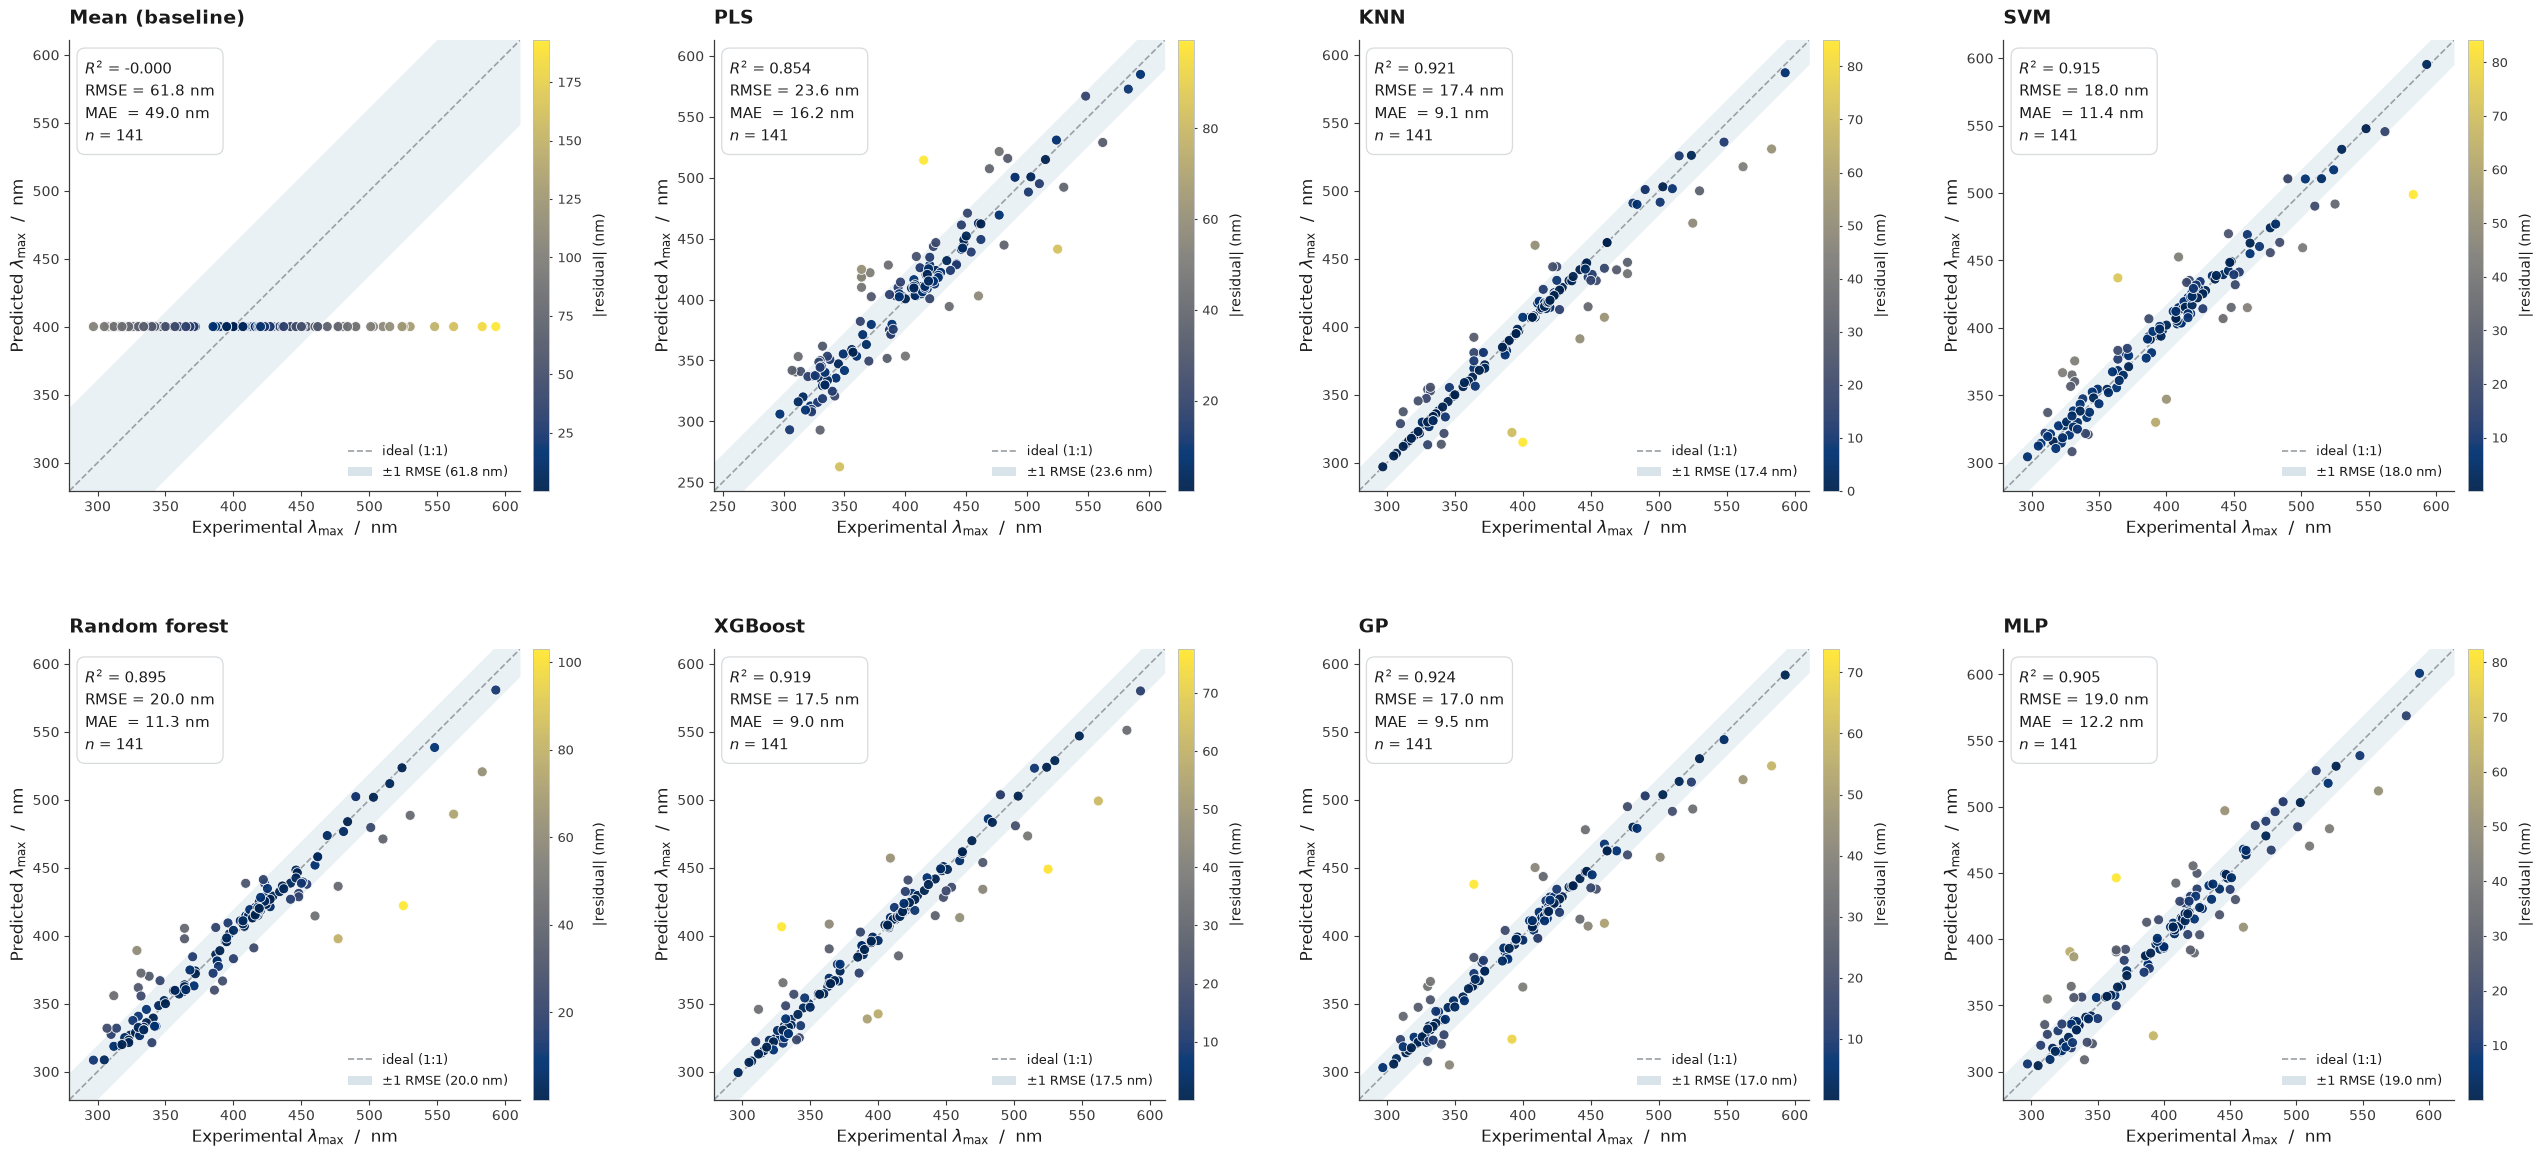

In [11]:
parity_grid(model_results, ncols=4, show_residuals=False)
plt.show()

## 5. How much is just split noise?
With datasets this small, the random data split alone moves the metrics. Repeat one setting over several seeds: **differences between settings that are smaller than this spread aren't meaningful.**

In [12]:
seeds = {f"seed {s}": [f"data.seed={s}"] for s in range(5)}
seed_summary, seed_results = run_grid(seeds, common=QUICK)
seed_summary[["rmse", "mae", "r2"]].agg(["mean", "std"])

    [INFO] 17:37:25 [Md:experiment Fn:run_experiment] === seed 0: ['trainer.n_trials=20', 'trainer.show_progress_bar=false', 'data.seed=0']
    [INFO] 17:37:35 [Md:optim_hp Fn:optimise_hyper_params] Study 'absorbance_model_2aee5c83': 0 trials done, running 20 more
    [INFO] 17:37:53 [Md:optim_hp Fn:optimise_hyper_params] Best test RMSE 22.262 with params {'max_depth': 3, 'learning_rate': 0.2970909662069416, 'n_estimators': 1782, 'subsample': 0.5947756220906528, 'colsample_bytree': 0.6732308419187306, 'min_child_weight': 3, 'gamma': 2.6668991472676473}
    [INFO] 17:37:53 [Md:experiment Fn:run] Val metrics: {'rmse': 24.322736571893845, 'mae': 14.68403051930962, 'r2': 0.8639222126916122, 'n_train': 700, 'n_val': 141, 'n_test': 93, 'n_features': 218}
    [INFO] 17:37:53 [Md:xgb Fn:save] Saved model to C:\Users\ollyb\Documents_Local\Code\ChemRover\outputs\notebook\2026-09-26\17-37-25_seed_0\absorbance_model.json
    [INFO] 17:37:54 [Md:experiment Fn:run_experiment] === seed 1: ['trainer.n

,rmse,mae,r2
mean,22.776,12.463,0.883
std,3.001,1.570,0.029


## 5b. Learning curve: does solvent help more as the data grows?
XGBoost on the combined dataset, trained on increasing fractions of the training split, **with and without solvent**.
- `data.train_fraction` shrinks only the training split. The test (tuning) and val (benchmark) sets stay fixed, so every point is scored on the same molecules.
- Smaller fractions are nested inside larger ones (the 5% sample is inside the 10% sample), and `data.required` means both solvent variants use identical rows. The only difference between the two lines is the solvent column.
- Each point is tuned separately (each fraction has its own Optuna study) and repeated over 3 split seeds, drawn as mean ± 1 sd.

**Reading it:** the vertical gap between the lines is what solvent adds at that data size. A line still falling at the right-hand edge means more data would still help; a flat line means the model or representation (or measurement noise) is the limit.

In [13]:
# 7 training sizes x with/without solvent x 3 split seeds = 42 runs (about 10 min with QUICK)
fractions = [0.05, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0]
curve_variants = product(
    solvent={"with solvent": [], "no solvent": "data.features=[lambda,SMILES]"},
    fraction={f"{f:.2f}": f"data.train_fraction={f}" for f in fractions},
    seed={str(s): f"data.seed={s}" for s in range(3)},
)
curve, curve_results = run_grid(curve_variants, common=QUICK + ["model=xgb", "data.subset=4"])
curve.index.names = ["solvent", "fraction", "seed"]

# mean and spread over the seeds at each training-set size
curve_stats = curve.groupby(["solvent", "n_train"])[["rmse", "mae", "r2"]].agg(["mean", "std"])
curve_stats

    [INFO] 17:39:43 [Md:experiment Fn:run_experiment] === with solvent | 0.05 | 0: ['trainer.n_trials=20', 'trainer.show_progress_bar=false', 'model=xgb', 'data.subset=4', 'data.train_fraction=0.05', 'data.seed=0']
    [INFO] 17:39:51 [Md:optim_hp Fn:optimise_hyper_params] Study 'absorbance_model_f4f42dbc': 0 trials done, running 20 more
    [INFO] 17:39:58 [Md:optim_hp Fn:optimise_hyper_params] Best test RMSE 44.222 with params {'max_depth': 9, 'learning_rate': 0.2099817632438527, 'n_estimators': 1484, 'subsample': 0.7124581989652701, 'colsample_bytree': 0.9579539671332897, 'min_child_weight': 2, 'gamma': 4.694416885230888}
    [INFO] 17:39:58 [Md:experiment Fn:run] Val metrics: {'rmse': 48.80937325775047, 'mae': 35.25077982151762, 'r2': 0.4520148007579736, 'n_train': 35, 'n_val': 141, 'n_test': 93, 'n_features': 218}
    [INFO] 17:39:58 [Md:xgb Fn:save] Saved model to C:\Users\ollyb\Documents_Local\Code\ChemRover\outputs\notebook\2026-09-26\17-39-43_with_solvent_0_05_0\absorbance_mod

rmse            mae            r2       
                        mean    std    mean    std   mean    std
solvent      n_train                                            
no solvent   35       43.614  4.682  30.615  3.517  0.553  0.085
             70       40.872  6.636  27.783  5.147  0.603  0.124
             140      37.443  2.056  23.314  1.629  0.672  0.033
             245      31.890  1.458  19.785  1.264  0.762  0.018
             350      30.388  2.852  18.268  2.565  0.783  0.038
             525      26.255  2.803  14.786  0.955  0.838  0.033
             700      22.026  1.504  11.806  0.084  0.886  0.014
with solvent 35       43.735  4.807  31.399  4.359  0.550  0.095
             70       38.751  4.855  27.345  5.303  0.646  0.085
             140      33.886  3.993  22.462  2.894  0.729  0.061
             245      31.768  3.990  20.437  2.959  0.762  0.056
             350      26.795  1.608  16.059  0.918  0.832  0.020
             525      24.529  4.056  14.342  2.366  0.857  0.046
             700      21.309  2.649  12.440  2.007  0.893  0.025

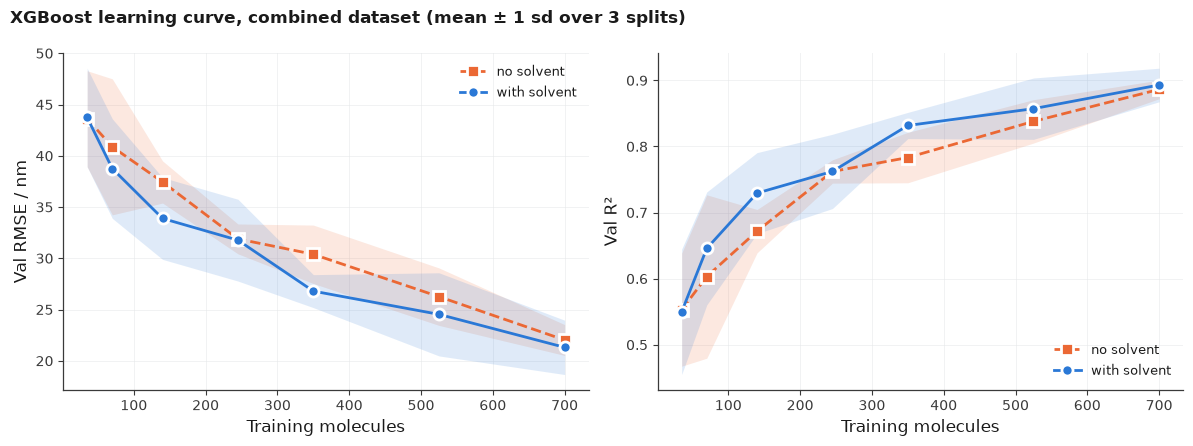

In [21]:
import matplotlib as mpl
from chemrover.plotting.pred_vs_measured import _RC   # same light style as the parity plots

colors = {"with solvent": "#2a78d6", "no solvent": "#eb6834"}    # categorical slots 1 and 2
styles = {"with solvent": ("o", "-"), "no solvent": ("s", "--")}  # marker + dash, so identity isn't colour alone


def plot_curve(ax, metric, ylabel, legend_loc):
    """Mean ± 1 sd of `metric` against training-set size, one line per solvent setting."""
    for solvent, grp in curve_stats.groupby(level="solvent"):
        n = grp.index.get_level_values("n_train")
        mean, std = grp[(metric, "mean")], grp[(metric, "std")]
        marker, ls = styles[solvent]
        ax.fill_between(n, mean - std, mean + std, color=colors[solvent], alpha=0.15, lw=0)
        ax.plot(n, mean, ls=ls, lw=2, marker=marker, ms=8, mec="white", mew=2,
                color=colors[solvent], label=solvent)
    ax.set(xlabel="Training molecules", ylabel=ylabel)
    ax.legend(loc=legend_loc)
    ax.grid(True, color="#e3e6e8", lw=0.7)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)


with mpl.rc_context(_RC):
    fig, (ax_rmse, ax_r2) = plt.subplots(1, 2, figsize=(12, 4.5))
    plot_curve(ax_rmse, "rmse", "Val RMSE / nm", legend_loc="upper right")
    plot_curve(ax_r2, "r2", "Val R²", legend_loc="lower right")
    fig.suptitle("XGBoost learning curve, combined dataset (mean ± 1 sd over 3 splits)",
                 x=0.01, ha="left", fontweight="bold")
    fig.tight_layout()
    plt.show()

In [15]:
# what solvent adds at each size: positive = including solvent lowers the val RMSE
gap = curve_stats[("rmse", "mean")].unstack("solvent")
gap["solvent benefit / nm"] = gap["no solvent"] - gap["with solvent"]
gap

solvent,no solvent,with solvent,solvent benefit / nm
n_train,,,
35,43.614,43.735,-0.121
70,40.872,38.751,2.121
140,37.443,33.886,3.557
245,31.890,31.768,0.122
350,30.388,26.795,3.592
525,26.255,24.529,1.726
700,22.026,21.309,0.717


## 5c. Learning curve by model
The same setup as 5b (combined dataset, fixed test and val sets, nested training subsets, 3 split seeds), with solvent included, comparing the models instead of the solvent setting. The mean baseline is left out: it can't improve with more data.

- **Size effect:** how each model's error falls as the training set grows, and which models do best with little data.
- **Split variation:** the spread over the 3 seeds at each size, i.e. how much a model's score depends on which molecules land in each split.

7 models × 7 sizes × 3 seeds = 147 runs, which takes roughly an hour with `QUICK` (random forest and GP dominate). To shorten it, trim `lc_models`, `lc_fractions` or the seeds.

In [22]:
lc_models = {
    "PLS": "model=pls", "KNN": "model=knn", "SVM": "model=svm", "Random forest": "model=rf",
    "XGBoost": "model=xgb", "GP": "model=gp", "MLP": "model=mlp",
}
lc_fractions = [0.05, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0]
model_curve, _ = run_grid(       # fitted models aren't kept: 147 of them would use a lot of memory
    product(
        model=lc_models,
        fraction={f"{f:.2f}": f"data.train_fraction={f}" for f in lc_fractions},
        seed={str(s): f"data.seed={s}" for s in range(3)},
    ),
    common=QUICK + ["data.subset=4"],
)
model_curve.index.names = ["model", "fraction", "seed"]

# mean and spread over the seeds, per model and training-set size (models kept in lc_models order)
model_curve_stats = model_curve.groupby(["model", "n_train"], sort=False)[["rmse", "mae", "r2"]].agg(["mean", "std"])
model_curve_stats

    [INFO] 18:30:44 [Md:experiment Fn:run_experiment] === PLS | 0.05 | 0: ['trainer.n_trials=20', 'trainer.show_progress_bar=false', 'data.subset=4', 'model=pls', 'data.train_fraction=0.05', 'data.seed=0']
    [INFO] 18:30:54 [Md:optim_hp Fn:optimise_hyper_params] Study 'absorbance_pls_1c3e8dd0': 0 trials done, running 20 more
    [INFO] 18:30:56 [Md:optim_hp Fn:optimise_hyper_params] Best test RMSE 27709.720 with params {'n_components': 1}
    [INFO] 18:30:56 [Md:experiment Fn:run] Val metrics: {'rmse': 22504.239290248843, 'mae': 1933.0030622786198, 'r2': -116489.64249967525, 'n_train': 35, 'n_val': 141, 'n_test': 93, 'n_features': 218}
    [INFO] 18:30:56 [Md:sklearn_base Fn:save] Saved model to C:\Users\ollyb\Documents_Local\Code\ChemRover\outputs\notebook\2026-09-26\18-30-44_PLS_0_05_0\absorbance_pls.joblib
    [INFO] 18:30:57 [Md:experiment Fn:run_experiment] === PLS | 0.05 | 1: ['trainer.n_trials=20', 'trainer.show_progress_bar=false', 'data.subset=4', 'model=pls', 'data.train_fr

C:\Users\ollyb\Documents_Local\Code\ChemRover\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


    [INFO] 19:02:31 [Md:experiment Fn:run_experiment] === GP | 0.05 | 1: ['trainer.n_trials=20', 'trainer.show_progress_bar=false', 'data.subset=4', 'model=gp', 'data.train_fraction=0.05', 'data.seed=1']
    [INFO] 19:02:44 [Md:optim_hp Fn:optimise_hyper_params] 'absorbance_gp' has no search space; fitting once with the configured params
    [INFO] 19:02:44 [Md:experiment Fn:run] Val metrics: {'rmse': 46.03295354125732, 'mae': 29.259609210739846, 'r2': 0.5066749130510032, 'n_train': 35, 'n_val': 141, 'n_test': 93, 'n_features': 218}
    [INFO] 19:02:44 [Md:sklearn_base Fn:save] Saved model to C:\Users\ollyb\Documents_Local\Code\ChemRover\outputs\notebook\2026-09-26\19-02-31_GP_0_05_1\absorbance_gp.joblib


C:\Users\ollyb\Documents_Local\Code\ChemRover\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


    [INFO] 19:02:45 [Md:experiment Fn:run_experiment] === GP | 0.05 | 2: ['trainer.n_trials=20', 'trainer.show_progress_bar=false', 'data.subset=4', 'model=gp', 'data.train_fraction=0.05', 'data.seed=2']
    [INFO] 19:02:57 [Md:optim_hp Fn:optimise_hyper_params] 'absorbance_gp' has no search space; fitting once with the configured params
    [INFO] 19:02:57 [Md:experiment Fn:run] Val metrics: {'rmse': 45.50879277225522, 'mae': 33.33112754128424, 'r2': 0.5059327783365154, 'n_train': 35, 'n_val': 141, 'n_test': 93, 'n_features': 218}
    [INFO] 19:02:57 [Md:sklearn_base Fn:save] Saved model to C:\Users\ollyb\Documents_Local\Code\ChemRover\outputs\notebook\2026-09-26\19-02-45_GP_0_05_2\absorbance_gp.joblib


...

C:\Users\ollyb\Documents_Local\Code\ChemRover\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 13 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


    [INFO] 19:03:55 [Md:experiment Fn:run] Val metrics: {'rmse': 34.252964471028974, 'mae': 19.426532363638316, 'r2': 0.7268558850891014, 'n_train': 140, 'n_val': 141, 'n_test': 93, 'n_features': 218}
    [INFO] 19:03:55 [Md:sklearn_base Fn:save] Saved model to C:\Users\ollyb\Documents_Local\Code\ChemRover\outputs\notebook\2026-09-26\19-03-43_GP_0_20_1\absorbance_gp.joblib
    [INFO] 19:03:56 [Md:experiment Fn:run_experiment] === GP | 0.20 | 2: ['trainer.n_trials=20', 'trainer.show_progress_bar=false', 'data.subset=4', 'model=gp', 'data.train_fraction=0.2', 'data.seed=2']
    [INFO] 19:04:07 [Md:optim_hp Fn:optimise_hyper_params] 'absorbance_gp' has no search space; fitting once with the configured params
    [INFO] 19:04:07 [Md:experiment Fn:run] Val metrics: {'rmse': 33.736808034051016, 'mae': 20.686914437107717, 'r2': 0.7284790202688529, 'n_train': 140, 'n_val': 141, 'n_test': 93, 'n_features': 218}
    [INFO] 19:04:07 [Md:sklearn_base Fn:save] Saved model to C:\Users\ollyb\Document

C:\Users\ollyb\Documents_Local\Code\ChemRover\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


    [INFO] 19:04:32 [Md:experiment Fn:run_experiment] === GP | 0.35 | 2: ['trainer.n_trials=20', 'trainer.show_progress_bar=false', 'data.subset=4', 'model=gp', 'data.train_fraction=0.35', 'data.seed=2']
    [INFO] 19:04:43 [Md:optim_hp Fn:optimise_hyper_params] 'absorbance_gp' has no search space; fitting once with the configured params
    [INFO] 19:04:44 [Md:experiment Fn:run] Val metrics: {'rmse': 28.1863652014961, 'mae': 17.210476004227374, 'r2': 0.8104719207199982, 'n_train': 245, 'n_val': 141, 'n_test': 93, 'n_features': 218}
    [INFO] 19:04:44 [Md:sklearn_base Fn:save] Saved model to C:\Users\ollyb\Documents_Local\Code\ChemRover\outputs\notebook\2026-09-26\19-04-32_GP_0_35_2\absorbance_gp.joblib
    [INFO] 19:04:45 [Md:experiment Fn:run_experiment] === GP | 0.50 | 0: ['trainer.n_trials=20', 'trainer.show_progress_bar=false', 'data.subset=4', 'model=gp', 'data.train_fraction=0.5', 'data.seed=0']
    [INFO] 19:04:58 [Md:optim_hp Fn:optimise_hyper_params] 'absorbance_gp' has no s

rmse                 mae                   r2  \
                           mean        std     mean       std       mean   
model         n_train                                                      
PLS           35       7541.546  12958.083  666.348  1096.956 -38829.822   
              70        189.513    248.738   41.906    23.339    -16.755   
              140       744.054   1224.827   89.210   112.082   -356.396   
              245      1157.351   1946.413  123.057   173.079   -888.058   
              350       714.302   1180.675   78.473    98.793   -330.129   
              525       354.168    557.305   46.620    45.897    -75.484   
              700        28.750      4.921   18.220     2.445      0.802   
KNN           35         44.951      2.477   32.902     0.909      0.527   
              70         39.859      2.297   27.331     1.607      0.628   
              140        36.289      2.129   23.391     1.942      0.692   
              245        35.464      3.794   21.734     4.219      0.704   
              350        32.414      1.949   18.250     0.247      0.754   
              525        29.446      6.274   15.606     2.947      0.792   
              700        25.841      1.347   12.856     0.637      0.844   
SVM           35         42.694      3.029   30.245     3.678      0.573   
              70         38.345      1.988   25.745     1.229      0.656   
              140        34.896      1.309   22.622     2.429      0.715   
              245        32.934      5.145   20.561     3.502      0.743   
              350        28.148      2.523   17.633     1.233      0.814   
              525        27.470      3.244   15.450     1.686      0.821   
              700        25.580      2.984   14.768     1.854      0.845   
Random forest 35         44.396      0.965   31.839     3.125      0.539   
              70         40.841      4.044   27.320     3.578      0.608   
              140        35.697      3.952   22.973     2.215      0.700   
              245        31.758      2.662   20.601     1.495      0.764   
              350        29.056      2.660   17.945     1.422      0.802   
              525        25.991      2.971   15.437     1.237      0.841   
              700        22.954      1.540   13.469     0.538      0.876   
XGBoost       35         43.735      4.807   31.399     4.359      0.550   
              70         38.751      4.855   27.345     5.303      0.646   
              140        33.886      3.993   22.462     2.894      0.729   
              245        31.768      3.990   20.437     2.959      0.762   
              350        26.795      1.608   16.059     0.918      0.832   
              525        24.529      4.056   14.342     2.366      0.857   
              700        21.309      2.649   12.440     2.007      0.893   
GP            35         46.276      0.914   31.785     2.205      0.499   
              70         37.868      3.133   24.472     0.920      0.663   
              140        33.501      0.893   20.016     0.634      0.737   
              245        30.678      2.511   18.247     1.152      0.779   
              350        26.981      2.803   15.378     1.252      0.829   
              525        25.594      1.396   13.779     0.706      0.847   
              700        22.839      1.622   11.527     0.807      0.878   
MLP           35       2288.355   3460.655  228.941   287.952  -3040.269   
              70       1021.033   1679.548  112.097   146.227   -671.373   
              140      1873.334   3153.557  182.906   276.262  -2331.239   
              245       169.756    237.736   34.988    21.736    -14.299   
              350       432.525    703.019   52.988    62.433   -117.823   
              525       101.637    132.707   22.600    12.618     -4.079   
              700        79.475     92.374   21.598     9.954     -1.764   

                                  
                             std  
mode

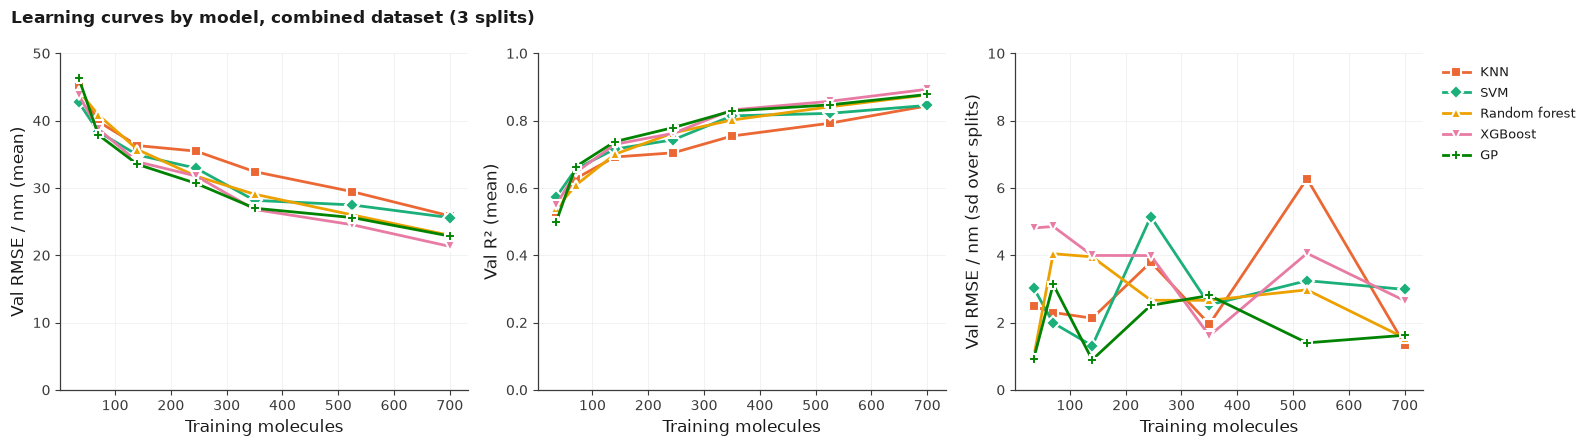

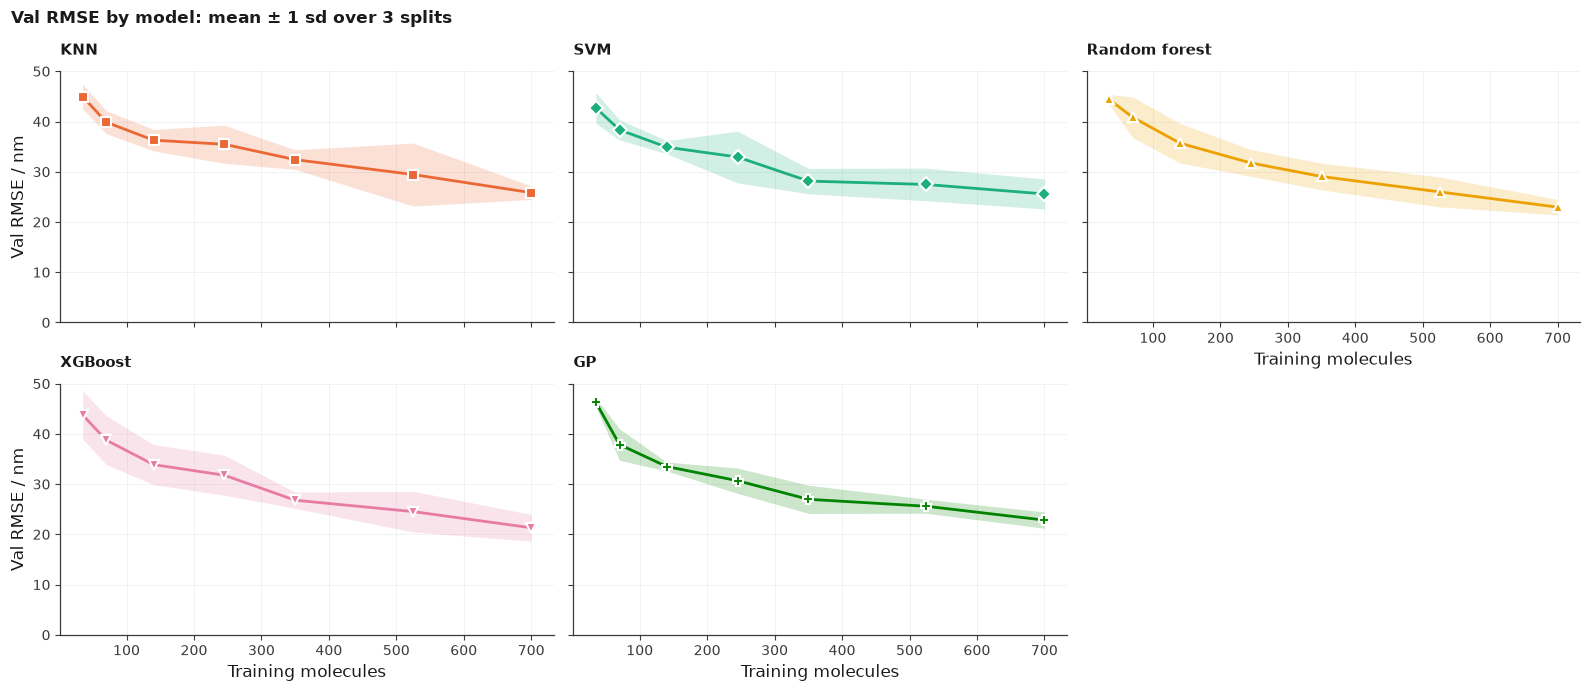

In [35]:
import matplotlib as mpl
from chemrover.plotting.pred_vs_measured import _RC   # same light style as the parity plots

# categorical slots 1-7 in fixed order, plus a distinct marker per model so identity isn't colour alone
model_colors = dict(zip(lc_models, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]))
model_markers = dict(zip(lc_models, "osD^vPX"))
by_model = list(model_curve_stats.groupby(level="model", sort=False))

# Filter
models_to_plot = ["KNN", "SVM", "Random forest", "XGBoost", "GP"]
temp = []
for model, grp in by_model:
    if model in models_to_plot:
        temp.append((model, grp))
by_model = temp

def style_axes(ax, ylabel):
    ax.set(xlabel="Training molecules", ylabel=ylabel)
    ax.grid(True, color="#e3e6e8", lw=0.7)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)


def plot_line(ax, model, grp, column, **kwargs):
    ax.plot(grp.index.get_level_values("n_train"), grp[column], lw=2, ms=7, mec="white", mew=1.5,
            marker=model_markers[model], color=model_colors[model], **kwargs)


with mpl.rc_context(_RC):
    # 1) all models together: dataset-size effect (means) and split variation (sd over seeds)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    panels = [(("rmse", "mean"), "Val RMSE / nm (mean)", (0, 50)),
              (("r2", "mean"),   "Val R² (mean)",        (0, 1)),
              (("rmse", "std"),  "Val RMSE / nm (sd over splits)", (0, 10))]
    for ax, (column, ylabel, ylim) in zip(axes, panels):
        for model, grp in by_model:
            plot_line(ax, model, grp, column, label=model)
        ax.set_ylim(*ylim)
        style_axes(ax, ylabel)
    axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    fig.suptitle("Learning curves by model, combined dataset (3 splits)", x=0.01, ha="left", fontweight="bold")
    fig.tight_layout()
    plt.show()

    # 2) one panel per model, shared axes: mean ± 1 sd band shows the split variation at each size
    fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=True, sharey=True)
    for ax, (model, grp) in zip(axes.flat, by_model):
        n, mean, std = grp.index.get_level_values("n_train"), grp[("rmse", "mean")], grp[("rmse", "std")]
        ax.fill_between(n, mean - std, mean + std, color=model_colors[model], alpha=0.2, lw=0)
        plot_line(ax, model, grp, ("rmse", "mean"))
        ax.set_title(model, loc="left", fontsize=11)
        ax.set_ylim(0, 50)
        style_axes(ax, "Val RMSE / nm")
        ax.label_outer()
    axes[1, 2].set_visible(False)                           # 7 models in a 2 x 4 grid
    axes[0, 2].tick_params(labelbottom=True)                # so the last column keeps its x axis
    axes[0, 2].set_xlabel("Training molecules")
    fig.suptitle("Val RMSE by model: mean ± 1 sd over 3 splits", x=0.01, ha="left", fontweight="bold")
    fig.tight_layout()
    plt.show()

In [ ]:
# each model at the smallest and the full training size, best first at full size
sizes = sorted(model_curve["n_train"].unique())
ends = pd.concat({f"{n} molecules": model_curve_stats.xs(n, level="n_train")[["rmse", "r2"]]
                  for n in (sizes[0], sizes[-1])}, axis=1)
ends.sort_values((f"{sizes[-1]} molecules", "rmse", "mean"))

## 6. Run history
Every saved run with a `metrics.json`, from the notebook and the CLI, newest first.

In [16]:
runs = load_runs()
runs.head(20)

,time,run,overrides,rmse,mae,r2,n_train,n_val,n_test,n_features
0,2026-09-26 17:55:07.009537,notebook/2026-09-26/17-54-33_no_solvent_1_00_2,trainer.n_trials=20 trainer.show_progress_bar=...,21.119,11.753,0.894,700,141,93,217
1,2026-09-26 17:54:33.079877,notebook/2026-09-26/17-54-08_no_solvent_1_00_1,trainer.n_trials=20 trainer.show_progress_bar=...,21.197,11.903,0.895,700,141,93,217
2,2026-09-26 17:54:07.454331,notebook/2026-09-26/17-53-38_no_solvent_1_00_0,trainer.n_trials=20 trainer.show_progress_bar=...,23.763,11.762,0.870,700,141,93,217
3,2026-09-26 17:53:38.110112,notebook/2026-09-26/17-53-07_no_solvent_0_75_2,trainer.n_trials=20 trainer.show_progress_bar=...,24.416,13.700,0.858,525,141,93,217
4,2026-09-26 17:53:06.260830,notebook/2026-09-26/17-52-44_no_solvent_0_75_1,trainer.n_trials=20 trainer.show_progress_bar=...,24.868,15.159,0.856,525,141,93,217
5,2026-09-26 17:52:44.046683,notebook/2026-09-26/17-52-19_no_solvent_0_75_0,trainer.n_trials=20 trainer.show_progress_bar=...,29.482,15.498,0.800,525,141,93,217
6,2026-09-26 17:52:18.870953,notebook/2026-09-26/17-51-55_no_solvent_0_50_2,trainer.n_trials=20 trainer.show_progress_bar=...,28.578,16.610,0.805,350,141,93,217
7,2026-09-26 17:51:54.364597,notebook/2026-09-26/17-51-33_no_solvent_0_50_1,trainer.n_trials=20 trainer.show_progress_bar=...,28.910,16.972,0.805,350,141,93,217
8,2026-09-26 17:51:33.038279,notebook/2026-09-26/17-51-11_no_solvent_0_50_0,trainer.n_trials=20 trainer.show_progress_bar=...,33.675,21.222,0.739,350,141,93,217
9,2026-09-26 17:51:11.213460,notebook/2026-09-26/17-50-46_no_solvent_0_35_2,trainer.n_trials=20 trainer.show_progress_bar=...,30.527,18.825,0.778,245,141,93,217


In [17]:
# e.g. every run that dropped solvent, best first
runs[runs["overrides"].str.contains("features=[lambda,SMILES]", regex=False)].sort_values("r2", ascending=False)

,time,run,overrides,rmse,mae,r2,n_train,n_val,n_test,n_features
69,2026-09-26 17:30:10.862561,notebook/2026-09-26/17-29-16_no_solvent,trainer.n_trials=80 trainer.show_progress_bar=...,17.948,9.319,0.916,700,141,93,217
55,2026-09-26 17:34:48.676391,notebook/2026-09-26/17-34-38_Combined_no_solvent,trainer.n_trials=20 trainer.show_progress_bar=...,17.948,9.319,0.916,700,141,93,217
63,2026-09-26 17:33:32.221384,notebook/2026-09-26/17-33-22_no_solvent,trainer.n_trials=20 trainer.show_progress_bar=...,17.948,9.319,0.916,700,141,93,217
1,2026-09-26 17:54:33.079877,notebook/2026-09-26/17-54-08_no_solvent_1_00_1,trainer.n_trials=20 trainer.show_progress_bar=...,21.197,11.903,0.895,700,141,93,217
0,2026-09-26 17:55:07.009537,notebook/2026-09-26/17-54-33_no_solvent_1_00_2,trainer.n_trials=20 trainer.show_progress_bar=...,21.119,11.753,0.894,700,141,93,217
2,2026-09-26 17:54:07.454331,notebook/2026-09-26/17-53-38_no_solvent_1_00_0,trainer.n_trials=20 trainer.show_progress_bar=...,23.763,11.762,0.870,700,141,93,217
59,2026-09-26 17:33:56.238006,notebook/2026-09-26/17-33-53_Griffiths_no_solvent,trainer.n_trials=20 trainer.show_progress_bar=...,24.870,15.907,0.862,155,32,20,217
3,2026-09-26 17:53:38.110112,notebook/2026-09-26/17-53-07_no_solvent_0_75_2,trainer.n_trials=20 trainer.show_progress_bar=...,24.416,13.700,0.858,525,141,93,217
4,2026-09-26 17:53:06.260830,notebook/2026-09-26/17-52-44_no_solvent_0_75_1,trainer.n_trials=20 trainer.show_progress_bar=...,24.868,15.159,0.856,525,141,93,217
57,2026-09-26 17:34:24.559685,notebook/2026-09-26/17-34-12_PCCP_no_solvent,trainer.n_trials=20 trainer.show_progress_bar=...,15.347,10.155,0.835,120,25,16,217


## 7. Inspect one run
`RunResult.predictions` holds the val-set predictions with any categorical context (e.g. solvent), which is useful for seeing where the errors come from.

In [18]:
res = results[("Combined", "with solvent")]
errors = res.predictions.assign(abs_err=res.predictions["residual"].abs())
errors.groupby("solvent", observed=True)["abs_err"].agg(["count", "mean", "max"]).sort_values("count", ascending=False)

,count,mean,max
solvent,,,
ethanol,95,8.373,62.915
acetonitrile,32,6.275,76.096
dimethyl sulfoxide,5,21.509,57.568
CH,2,4.839,6.077
Alk,1,8.742,8.742
Benz,1,35.372,35.372
Chl,1,7.052,7.052
MeOH,1,77.540,77.540
DMSO,1,18.889,18.889


## 8. Your experiment
Copy this cell to test anything else.

In [19]:
my_variants = {
    "coverage 0.90": ["data.coverage_thresh=0.90"],
    "coverage 0.99": ["data.coverage_thresh=0.99"],
}
my_summary, my_results = run_grid(my_variants, common=QUICK)
my_summary

    [INFO] 17:55:08 [Md:experiment Fn:run_experiment] === coverage 0.90: ['trainer.n_trials=20', 'trainer.show_progress_bar=false', 'data.coverage_thresh=0.90']
    [INFO] 17:55:18 [Md:optim_hp Fn:optimise_hyper_params] Study 'absorbance_model_180dea13': 80 trials done, running 0 more
    [INFO] 17:55:18 [Md:optim_hp Fn:optimise_hyper_params] Best test RMSE 17.049 with params {'max_depth': 8, 'learning_rate': 0.06541821473314273, 'n_estimators': 2504, 'subsample': 0.6290101975389802, 'colsample_bytree': 0.6605839989206406, 'min_child_weight': 3, 'gamma': 4.54411713028876}
    [INFO] 17:55:21 [Md:experiment Fn:run] Val metrics: {'rmse': 17.53197138455609, 'mae': 8.984423265389516, 'r2': 0.9194255005300055, 'n_train': 700, 'n_val': 141, 'n_test': 93, 'n_features': 218}
    [INFO] 17:55:21 [Md:xgb Fn:save] Saved model to C:\Users\ollyb\Documents_Local\Code\ChemRover\outputs\notebook\2026-09-26\17-55-08_coverage_0_90\absorbance_model.json
    [INFO] 17:55:21 [Md:experiment Fn:run_experimen

,rmse,mae,r2,n_train,n_val,n_test,n_features
coverage 0.90,17.532,8.984,0.919,700,141,93,218
coverage 0.99,17.431,9.556,0.920,700,141,93,218
